# Convergence of MOU and rDCM derived EC

## Environment setup & index configuration

In [1]:
import os
import os.path
from os.path import dirname, join as pjoin
import numpy as np

import scipy.linalg as spl
import scipy.io as sio
from scipy import stats, odr
from scipy.stats import sem
import scipy.stats as stt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter

import seaborn as sb
import pandas as pd


from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

import networkx as nx
from pathlib import Path

# Jupyter magic commands
%matplotlib inline

### Load MOU Results

In [2]:
#out_path = '/home/nicolas/Documents/RetNet/ret-EC/new_results/'
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/temp/results_MOU/"

# Index dictionary
conf = {
        'tasks'   : ['vfm','movie','rest'], 
        'eccen'   : ['fovea','para-fovea'], 
        'fovea'   : [ 
                    [0,2,4,6,8,10,12,14,16,18,20,22],  #  < fovea
                    [1,3,5,7,9,11,13,15,17,19,21,23],   #  > fovea
                    ],
        'roiname' : ['V1','V2','V3'], 
        'rois'    : [
                    [0,1,2,3,12,13,14,15],   # V1
                    [4,5,6,7,16,17,18,19],   # V2
                    [8,9,10,11,20,21,22,23]  # V3
                    ],
        'task'    : [
                    [0,1],     # retinotopy
                    [2,3,4,5], # movie watching
                    [6,7,8,9]  # resting state
                    ],

        'hemis'   : ['left', 'right'],
        'flows'   : ['outflow', 'inflow']
        }

# Define the conditions and the corresponding filenames
conditions = conf['tasks']
model = 'new_2021'  # Replace with your actual model name

# Initialize lists to store the loaded data
model_fit_list = []
model_error_list = []
J_mod_list = []
Sigma_mod_list = []
tau_x_list = []
tau_list = []

# Load the MOU results
appendix = model 
model_fit = np.load(os.path.join(save_path, 'Fit_' + appendix + '.npy'))
model_error = np.load(os.path.join(save_path, 'Error_' + appendix + '.npy'))
J_mod = np.load(os.path.join(save_path, 'J_mod_' + appendix + '.npy'))
Sigma_mod = np.load(os.path.join(save_path, 'Sigma_mod_' + appendix + '.npy'))



# Print shapes of all arrays to determine the correct axis for subject removal
print("Current shapes before removal:")
print(f"model_fit: {model_fit.shape}")
print(f"model_error: {model_error.shape}")
print(f"J_mod: {J_mod.shape}")
print(f"Sigma_mod: {Sigma_mod.shape}")
#print(f"tau_x: {tau_x.shape}")
#print(f"tau: {tau.shape}")

Current shapes before removal:
model_fit: (3, 156)
model_error: (3, 156)
J_mod: (3, 156, 24, 24)
Sigma_mod: (3, 156, 24, 24)


## Load rDCM results

In [ ]:
model = 'rDCM_2024' 

out_path = "../../../temp/results_rDCM/"
print("Loading results from:", Path(out_path).resolve())

# Load pre-averaged results directly
EC_avg_dcm = np.load(os.path.join(out_path, "EC_avg_" + model + ".npy"))
diagonals_dcm = np.load(os.path.join(out_path, "diagonals_" + model + ".npy"))
F_avg_dcm = np.load(os.path.join(out_path, "F_avg_" + model + ".npy"))

print('EC_avg_dcm shape:', EC_avg_dcm.shape)       # Expected: (3, 156, 24, 24)
print('diagonals_dcm shape:', diagonals_dcm.shape) # Expected: (3, 156, 24)
print('F_avg_dcm shape:', F_avg_dcm.shape)         # Expected: (10, 156) or (3, 156) if you saved F_avg


out_pth = '/media/nicolas/KINGSTON/retNet_final/output'


Loading results from: /home/nicolas/Documents/GitHubProjects/retNet/temp/results_rDCM
EC_avg_dcm shape: (3, 156, 24, 24)
diagonals_dcm shape: (3, 156, 24)
F_avg_dcm shape: (3, 156)


## Normalize EC matrices 

To make EC matrices comparable across participants and conditions, each matrix is scaled by its L1 norm. This preserves relative differences in connection strengths while removing variations in overall magnitude.

In [4]:
def normalize_connectivity_matrices(EC_data, normalization_type='L1', verbose=True):
    """
    Normalize effective connectivity matrices using L1 or L2 normalization.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    normalization_type : str, optional
        Type of normalization to apply: 'L1' or 'L2' (default: 'L2')
        - 'L1': Normalize by sum of values (Manhattan norm)
        - 'L2': Normalize by Euclidean norm
    verbose : bool, optional
        Whether to print normalization information (default: True)
    
    Returns
    -------
    EC_normalized : ndarray
        Normalized connectivity matrices with same shape as input
    norm_name : str
        Name of the normalization method used
    
    Notes
    -----
    - Diagonal elements are set to zero before and after normalization
    - If the norm is zero, the matrix is returned unchanged
    """
    # Get dimensions
    n_cond, n_sub, n_rois, _ = EC_data.shape
    
    # Initialize output array
    EC_normalized = np.zeros((n_cond, n_sub, n_rois, n_rois))
    
    # Normalize each condition and subject
    for i_cond in range(n_cond):
        for i_sub in range(n_sub):

            # Get connectivity matrix for this condition and subject
            EC = EC_data[i_cond, i_sub, :, :].copy()
            np.fill_diagonal(EC, 0)  # zero out diagonal
            ECflat  = EC.flatten() # flatten the matrix
            

            # Get off-diagonal elements (link weights)
            EClinks = EC[~np.eye(EC.shape[0],dtype=bool)].reshape(EC.shape[0],-1) # ignore diagonal
            EClinks = EClinks.flatten() # flatten the links
            
            if normalization_type == 'L1':

                norm = sum(EClinks)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))

            elif normalization_type == 'L2':

                norm = np.sqrt(sum(EClinks)**2)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))
           
            
            # Ensure diagonal remains zero
            np.fill_diagonal(ECnorm, 0)
            
            # Store the normalized matrix
            EC_normalized[i_cond, i_sub, :, :] = ECnorm
    
    # Print information if verbose
    if verbose:
        print(f'EC shape: {EC_normalized.shape}, normalized using {normalization_type} norm')
    
    return EC_normalized


In [5]:
EC_normed_MOU = normalize_connectivity_matrices(
    EC_data=J_mod,
    normalization_type='L1',
    verbose=True
)

EC_normed_rDCM = normalize_connectivity_matrices(
    EC_data=EC_avg_dcm,
    normalization_type='L1',
    verbose=True
)

EC shape: (3, 156, 24, 24), normalized using L1 norm
EC shape: (3, 156, 24, 24), normalized using L1 norm


## Principal Component Analysis

In [6]:
X_mou = EC_normed_MOU.reshape((3*156,24*24))
X_dcm = EC_normed_rDCM.reshape((3*156,24*24))

X_mou= X_mou / np.std(X_mou)
X_dcm = X_dcm / np.std(X_dcm)

y = np.repeat(np.arange(3).reshape(3,1),156,axis=1).reshape((3*156))

### MOU

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

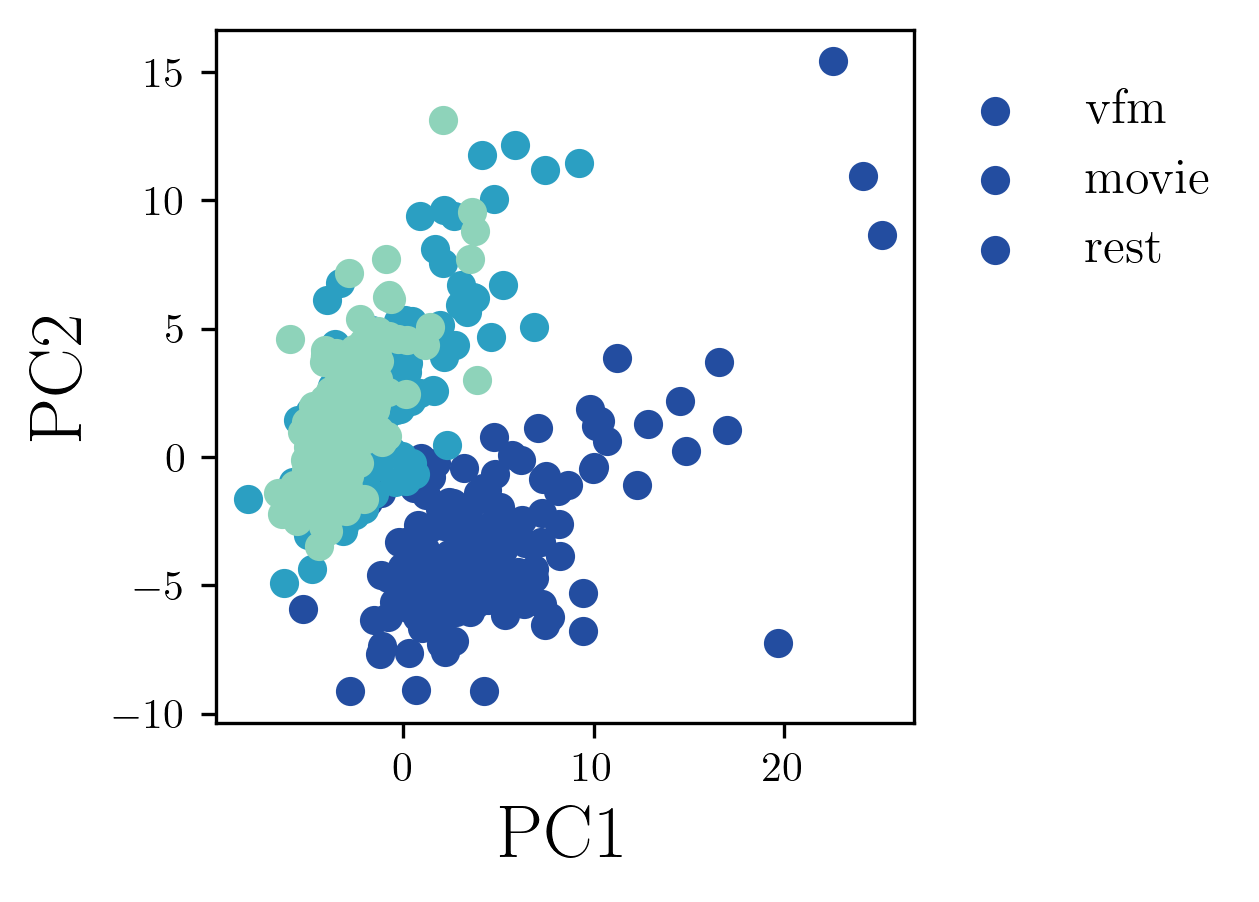

In [ ]:
X_mou = EC_normed_MOU.reshape((3*156,24*24))
X_dcm = EC_normed_rDCM.reshape((3*156,24*24))

X_mou= X_mou / np.std(X_mou)
X_dcm = X_dcm / np.std(X_dcm)

y = np.repeat(np.arange(3).reshape(3,1),156,axis=1).reshape((3*156))


pca = PCA(n_components=2)

plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(3,3), dpi=300, facecolor="w")
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))

x_pca = pca.fit_transform(X_mou)

cols = ['r', 'g', 'b']
for i in range(156*3):
    ax.scatter(x_pca[i,0], x_pca[i,1], c=colors[int(y[i])*3]) 
ax.set_xlabel('PC1', fontsize=18, weight='bold')
ax.set_ylabel('PC2', fontsize=18, weight='bold')

ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + '/PCA_MOU.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')

### rDCM

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

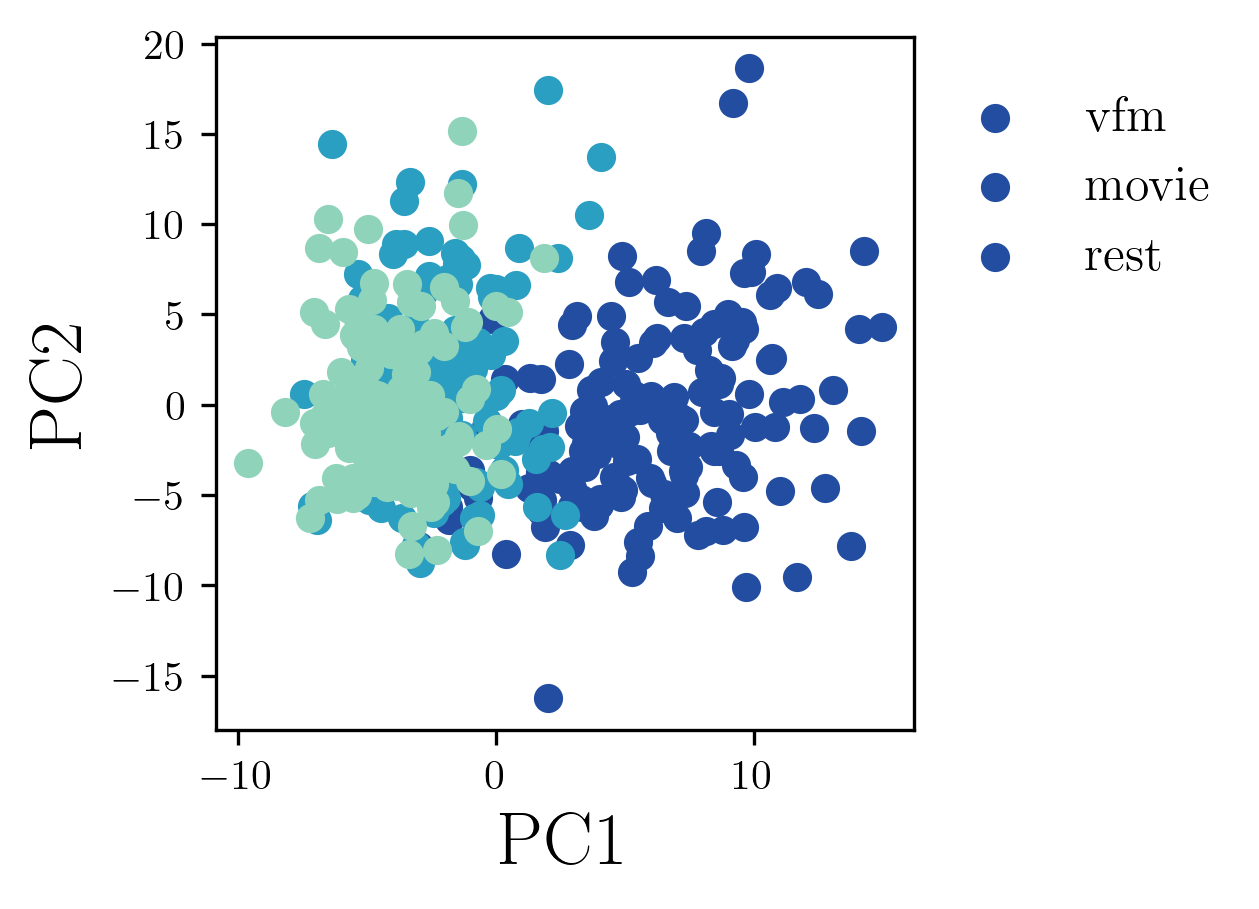

In [ ]:

pca = PCA(n_components=2)

fig, ax = plt.subplots(figsize=(3,3), dpi=300, facecolor="w")
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))

x_pca = pca.fit_transform(X_dcm)

cols = ['r', 'g', 'b']
for i in range(156*3):
    ax.scatter(x_pca[i,0], x_pca[i,1], c=colors[int(y[i])*3]) 

ax.set_xlabel('PC1', fontsize=18, weight='bold')
ax.set_ylabel('PC2', fontsize=18, weight='bold')

ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + '/PCA_rDCM.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')


### MOU vs rDCM

In [27]:
EC_normed_MOU.shape

(3, 156, 24, 24)

In [28]:
EC_normed_rDCM.shape

(3, 156, 24, 24)

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


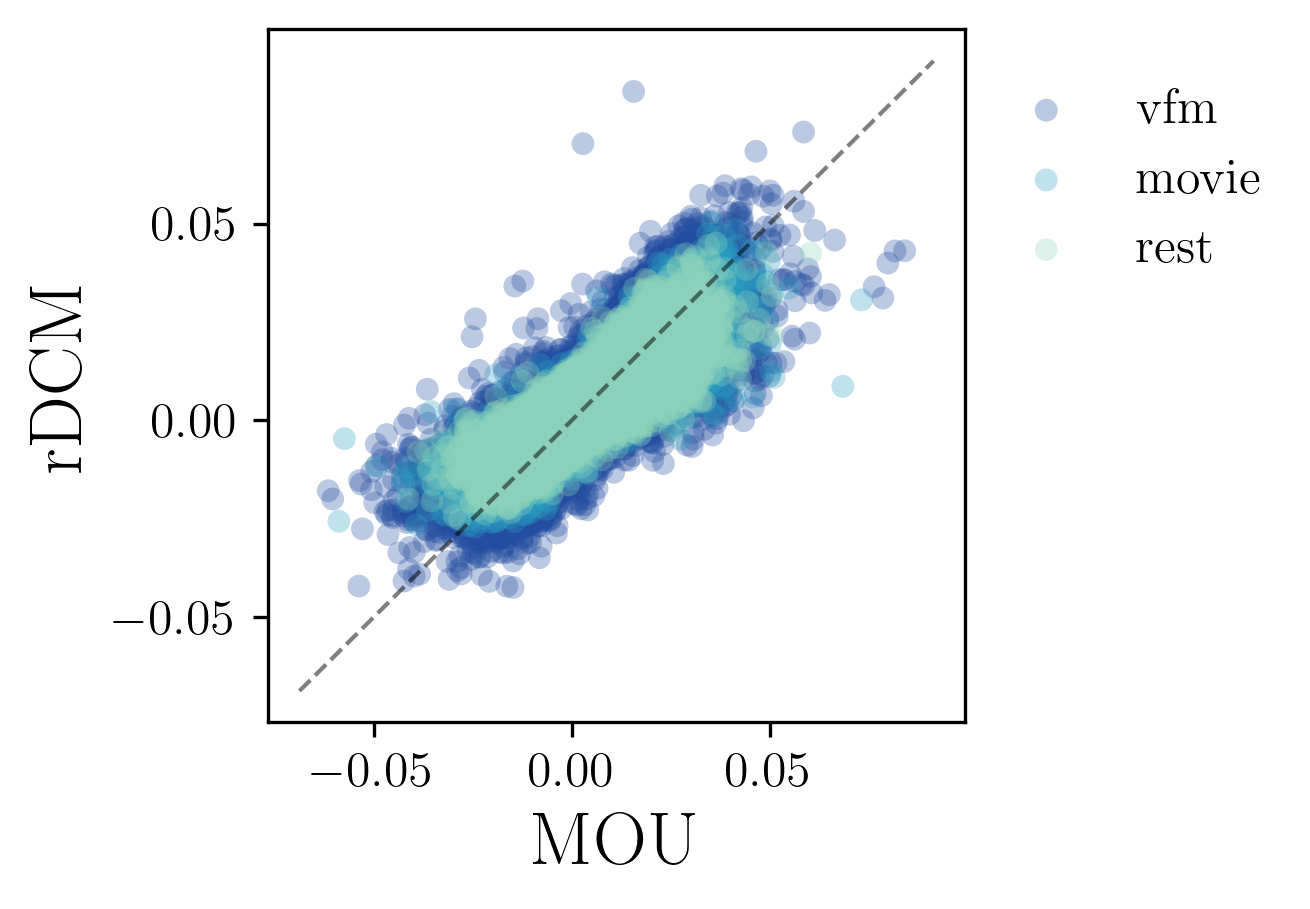

In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2, 0.8, n))
colors_cb = [colors[0], colors[3], colors[6]]  
labels = ['vfm', 'movie', 'rest']

fig, ax = plt.subplots(figsize=(3, 3), dpi=300, facecolor="w")

for i_cond in range(3):
    x = EC_normed_MOU[i_cond, :, :, :].flatten()
    y = EC_normed_rDCM[i_cond, :, :, :].flatten()
    r, p = stt.pearsonr(x, y)
    
    # Format p-value (use proper LaTeX for < symbol)
    if p < 0.001:
        p_str = r'$p\textless 0.001$'
    else:
        p_str = f'$p={p:.3f}$'
    
    # Rasterize scatter points to reduce SVG size
    ax.scatter(x, y, c=colors_cb[i_cond], alpha=0.3, s=30, 
               edgecolors='none', label=f'{labels[i_cond]} ($r={r:.2f}$, {p_str})',
               rasterized=True)

ax.set_xlabel('MOU ', fontsize=18, weight='bold')
ax.set_ylabel('rDCM ', fontsize=18, weight='bold')
ax.tick_params(axis='both', labelsize=12)

# Add diagonal reference line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), 
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--k', alpha=0.5, linewidth=1)

ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + '/MOU_vs_rDCM_scatter.svg'
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
            facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

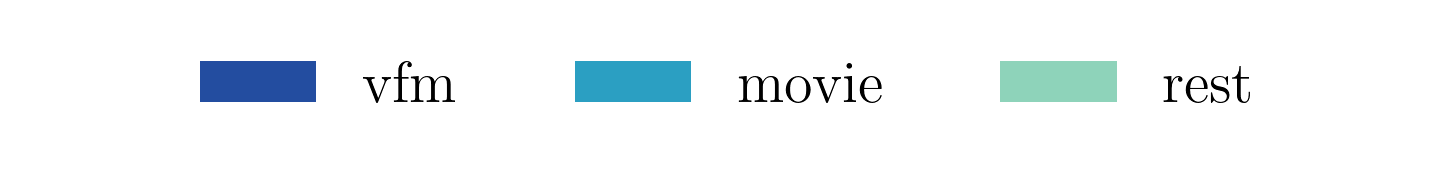

In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2, 0.8, n))
colors_cb = [colors[0], colors[3], colors[6]]  
labels = ['vfm', 'movie', 'rest']

# Create a minimal figure just for the legend
from matplotlib.patches import Patch

fig = plt.figure(figsize=(6, 0.5), dpi=300, facecolor="w")
ax = fig.add_subplot(111)
ax.axis('off')  # Hide the axes

# Create legend elements
legend_elements = [Patch(facecolor=colors_cb[i], edgecolor='none', label=labels[i]) for i in range(3)]

# Add horizontal legend
legend = ax.legend(handles=legend_elements, loc='center', ncol=3, 
                   frameon=False, fontsize=14)

fname = out_pth + '/Legend_only.svg' 
plt.savefig(fname, transparent=True, dpi='figure', format='svg',
            facecolor='none', edgecolor='none', bbox_inches='tight')

plt.show()

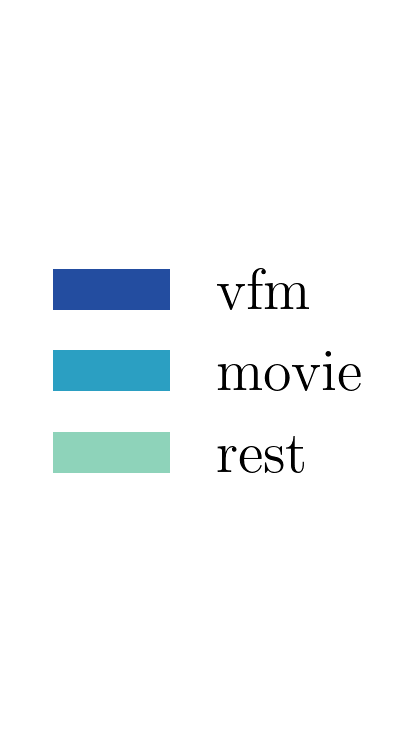

In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2, 0.8, n))
colors_cb = [colors[0], colors[3], colors[6]]  
labels = ['vfm', 'movie', 'rest']

# Create a minimal figure just for the legend
from matplotlib.patches import Patch

fig = plt.figure(figsize=(1.5, 3), dpi=300, facecolor="w")
ax = fig.add_subplot(111)
ax.axis('off')  # Hide the axes

# Create legend elements
legend_elements = [Patch(facecolor=colors_cb[i], edgecolor='none', label=labels[i]) for i in range(3)]

# Add vertical legend
legend = ax.legend(handles=legend_elements, loc='center', ncol=1, 
                   frameon=False, fontsize=14)

fname = out_pth + '/Legend_only.svg' 
plt.savefig(fname, transparent=True, dpi='figure', format='svg',
            facecolor='none', edgecolor='none', bbox_inches='tight')

plt.show()

## Variability in within-hemisphere connections

## Variability in callosal connections

Callosal connections are less affected by local vascular signal spread across V1–V3 and therefore exhibit lower variability.

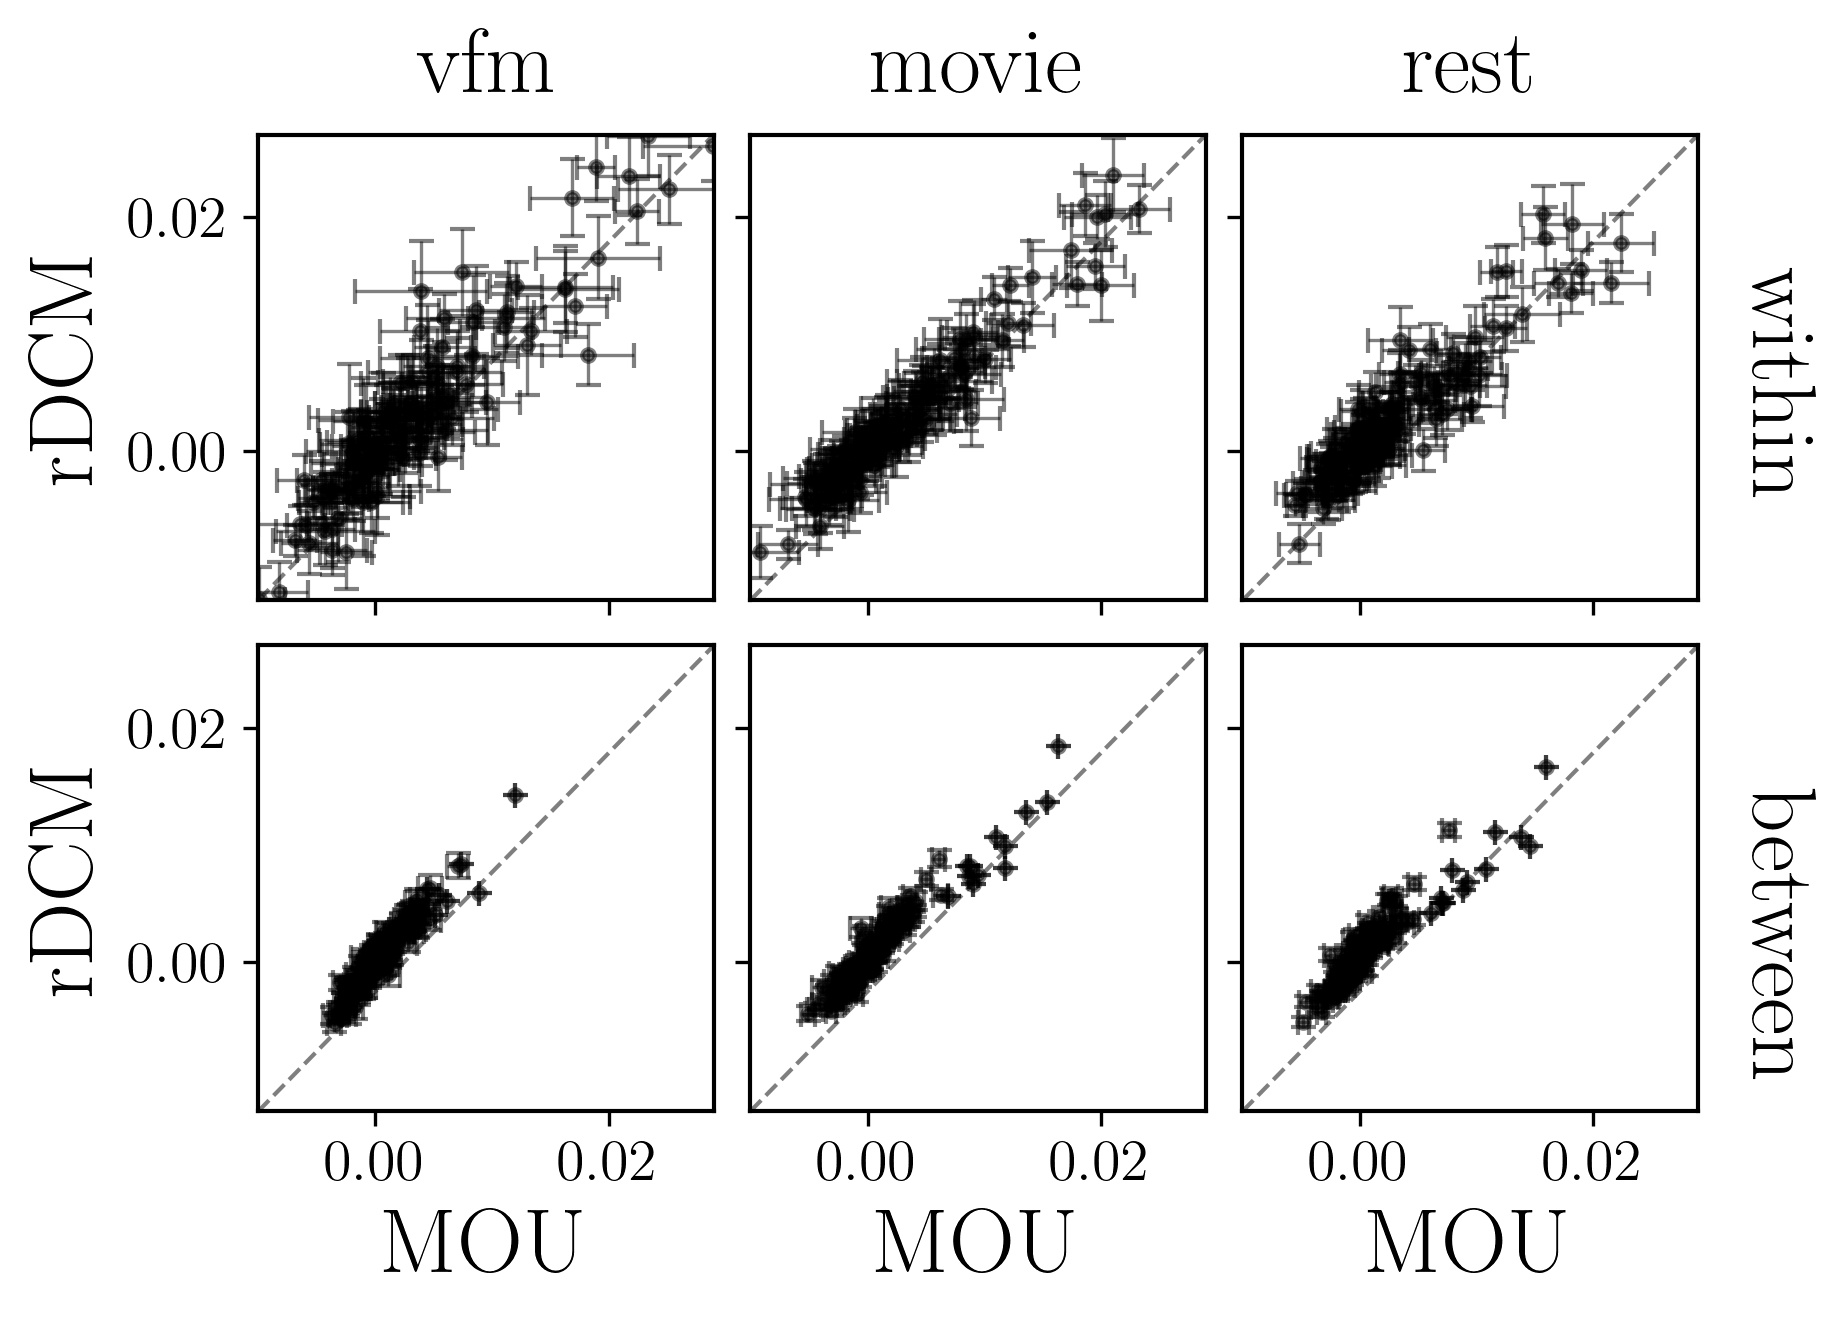


Within-hemisphere correlations:
vfm: PearsonRResult(statistic=0.9260894211209972, pvalue=5.5985517659497575e-62)
movie: PearsonRResult(statistic=0.9719730280502413, pvalue=3.573373597055484e-91)
rest: PearsonRResult(statistic=0.9286876445442753, pvalue=4.8414587374714395e-63)

Between-hemisphere correlations:
vfm: PearsonRResult(statistic=0.9529489598409404, pvalue=1.7263373652392927e-75)
movie: PearsonRResult(statistic=0.9612103843626386, pvalue=2.570281820838483e-81)
rest: PearsonRResult(statistic=0.9359738591161524, pvalue=2.9824675050069767e-66)


In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

n_rois = 12
n_cond = 3
n_sub = 156

# Set all colors to black
colors_cb = ['k', 'k', 'k']  # Black for all conditions
labels = ['vfm', 'movie', 'rest']

# Prepare data for both within and between hemisphere connections
xm_within = np.zeros((3,12,12))
ym_within = np.zeros((3,12,12))
xm_between = np.zeros((3,12,12))
ym_between = np.zeros((3,12,12))

# Compute within-hemisphere data
for i_cond in range(n_cond):
    for p in range(12):
        for q in range(12):
            x_within = EC_normed_MOU[i_cond, :10, p, q].flatten()
            y_within = EC_normed_rDCM[i_cond, :10, p, q].flatten()
            xm_within[i_cond,p,q] = np.mean(x_within)
            ym_within[i_cond,p,q] = np.mean(y_within)
            
            x_between = EC_normed_MOU[i_cond, :, p, q+12 if q<12 else q-12].flatten()
            y_between = EC_normed_rDCM[i_cond, :, p, q+12 if q<12 else q-12].flatten()
            xm_between[i_cond,p,q] = np.mean(x_between)
            ym_between[i_cond,p,q] = np.mean(y_between)

# Find global axis limits across all conditions
all_x = np.concatenate([xm_within.flatten(), xm_between.flatten()])
all_y = np.concatenate([ym_within.flatten(), ym_between.flatten()])
xlim = [all_x.min() - 0.0001, all_x.max() + 0.0001]
ylim = [all_y.min() - 0.0001, all_y.max() + 0.0001]

# Create figure with gridspec - tighter spacing
fig = plt.figure(figsize=(6, 4), dpi=300, facecolor="w")
gs = fig.add_gridspec(2, 3, hspace=0.08, wspace=0.08, 
                      left=0.12, right=0.92, top=0.94, bottom=0.12)

# Row 1: Within-hemisphere connections
for i_cond in range(n_cond):
    ax = fig.add_subplot(gs[0, i_cond])
    
    # Only add title to top row
    ax.set_title(labels[i_cond], fontsize=22, weight='bold', pad=10)
    
    for p in range(12):
        for q in range(12):
            x = EC_normed_MOU[i_cond, :10, p, q].flatten()
            y = EC_normed_rDCM[i_cond, :10, p, q].flatten()
            xerr = sem(x)
            yerr = sem(y)
            
            ax.errorbar(xm_within[i_cond,p,q], ym_within[i_cond,p,q], 
                       xerr=xerr, yerr=yerr, fmt='o', capsize=3, 
                       color='k', alpha=0.5, 
                       markersize=3, linewidth=0.8, rasterized=True)
    
    # Make subplot square
    ax.set_aspect('equal', adjustable='box')
    
    # Add diagonal and set limits
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], '--k', alpha=0.5, linewidth=1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # Only show x-label on bottom row 
    ax.set_xticklabels([])
    
    # Only show y-axis on leftmost column
    if i_cond == 0:
        ax.set_ylabel('rDCM', fontsize=22, weight='bold')
    else:
        ax.set_yticklabels([])
    
    ax.tick_params(axis='both', labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Row 2: Between-hemisphere (callosal) connections
for i_cond in range(n_cond):
    ax = fig.add_subplot(gs[1, i_cond])
    
    for p in range(12):
        for q in range(12):
            x = EC_normed_MOU[i_cond, :, p, q].flatten()
            y = EC_normed_rDCM[i_cond, :, p, q].flatten()
            xerr = sem(x)
            yerr = sem(y)
            
            ax.errorbar(xm_between[i_cond,p,q], ym_between[i_cond,p,q], 
                       xerr=xerr, yerr=yerr, fmt='o', capsize=3, 
                       color='k', alpha=0.5, 
                       markersize=3, linewidth=0.8, rasterized=True)
    
    # Make subplot square
    ax.set_aspect('equal', adjustable='box')
    
    # Add diagonal and set limits
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], '--k', alpha=0.5, linewidth=1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # Only show x-label on bottom row
    ax.set_xlabel('MOU', fontsize=22, weight='bold')
    
    # Only show y-axis on leftmost column
    if i_cond == 0:
        ax.set_ylabel('rDCM', fontsize=22, weight='bold')
    else:
        ax.set_yticklabels([])
    
    ax.tick_params(axis='both', labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Add row labels on the right
fig.text(0.94, 0.73, 'within ', fontsize=22, weight='bold', 
         rotation=270, va='center', ha='left')
fig.text(0.94, 0.27, 'between', fontsize=22, weight='bold', 
         rotation=270, va='center', ha='left')

fname = out_pth + '/Hemis_Alignment_grid.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
            facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

print("\nWithin-hemisphere correlations:")
for i_cond in range(n_cond):
    print(f"{labels[i_cond]}: {stt.pearsonr(xm_within[i_cond,:,:].flatten(), ym_within[i_cond,:,:].flatten())}")

print("\nBetween-hemisphere correlations:")
for i_cond in range(n_cond):
    print(f"{labels[i_cond]}: {stt.pearsonr(xm_between[i_cond,:,:].flatten(), ym_between[i_cond,:,:].flatten())}")

## Model convergence

MOU and rDCM estimates are robustly correlated and stabilize > participants.

[  2   4   8  16  32  64 128]


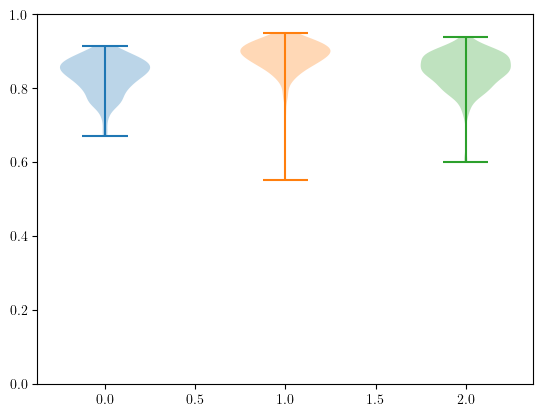

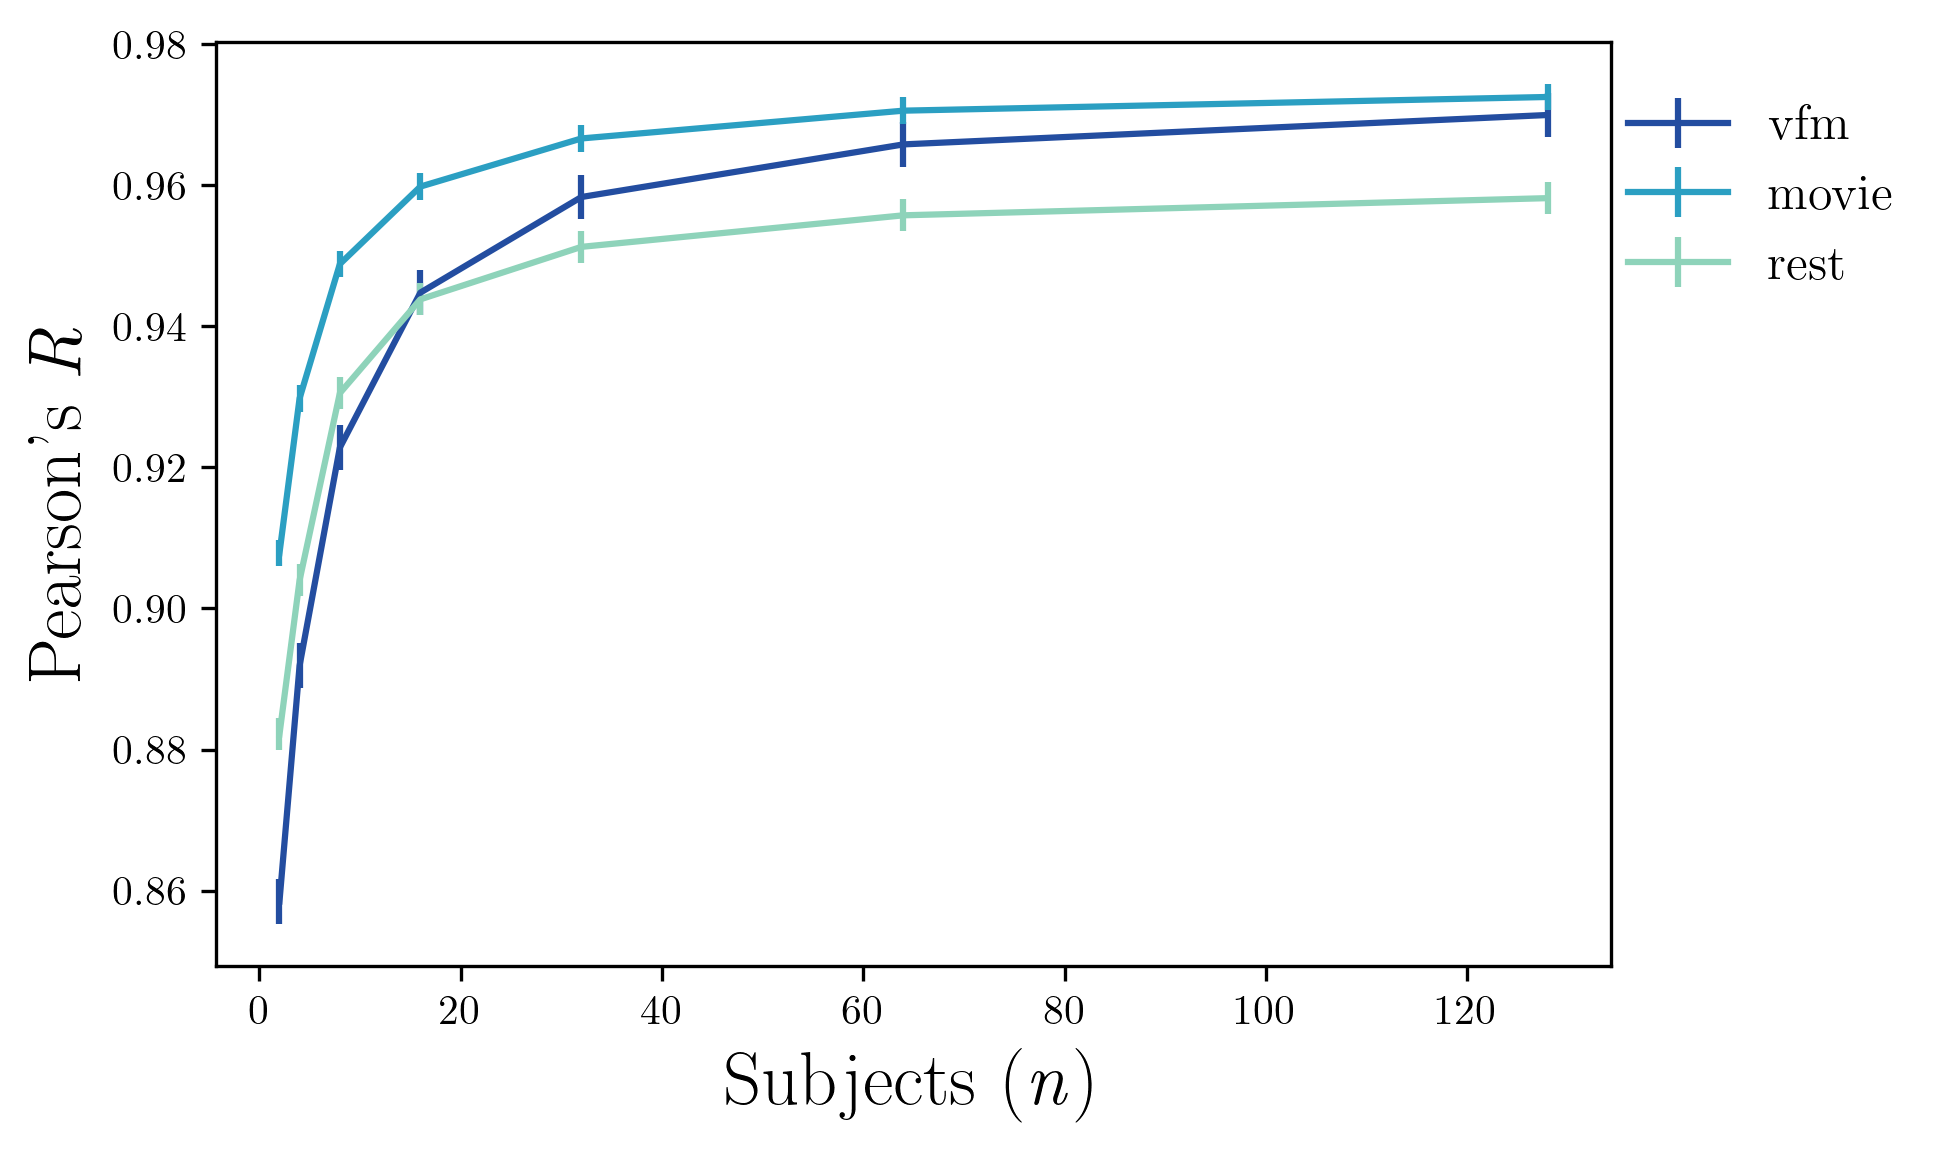

In [50]:
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))


# stats
R2_cond = []
for i_cond in range(n_cond):
    R2_cond.append([])
    for i_sub in range(156):
        R2_cond[i_cond].append(stt.pearsonr(EC_normed_rDCM[i_cond,i_sub,:,:].flatten(), EC_normed_MOU[i_cond,i_sub,:,:].flatten())[0])

plt.figure()
for i_cond in range(n_cond):
    plt.violinplot(R2_cond[i_cond], positions=[i_cond])
plt.axis(ymin=0.0, ymax=1.0)

#print(EC_dcm.shape)

n_rep = 100
v_n = np.array([2,4,8,16,32,64,128])
print(v_n)
R2_cond_av = np.zeros([n_cond,n_rep, v_n.size])
for i_rep in range(n_rep):
    for i_n, n in enumerate(v_n):
        #print(n)
        ind_sub = np.random.choice(np.arange(156), size=n, replace=False)
        for i_cond in range(n_cond):
            av_EC_dcm = EC_normed_rDCM[i_cond,ind_sub,:,:].mean(0)
            av_EC_mou = EC_normed_MOU[i_cond,ind_sub,:,:].mean(0)
            R2_cond_av[i_cond,i_rep,i_n] = stt.pearsonr(av_EC_dcm.flatten(), av_EC_mou.flatten())[0]


fig, ax = plt.subplots(figsize=(6, 4), dpi=300, facecolor="w")

for i_cond in range(n_cond):
    y = R2_cond_av[i_cond,:,:].mean(0)
    yerr = sem(R2_cond_av[i_cond,:,:].flatten())
    ax.errorbar(v_n, y, yerr=yerr*1.96, label=i_cond,color=colors[i_cond*3])

#ax.legend(['vfm','movie','rs'],loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylabel('Pearson\'s $\mathit{R}$', fontsize=18)
ax.set_xlabel('Subjects ($\mathit{n}$)', fontsize=18)
ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + 'MOU-rDCM_Alignment.png' 
plt.savefig(fname, transparent=None, dpi='figure', format='png',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')



#plt.axis(ymin=0.0, ymax=1.0)


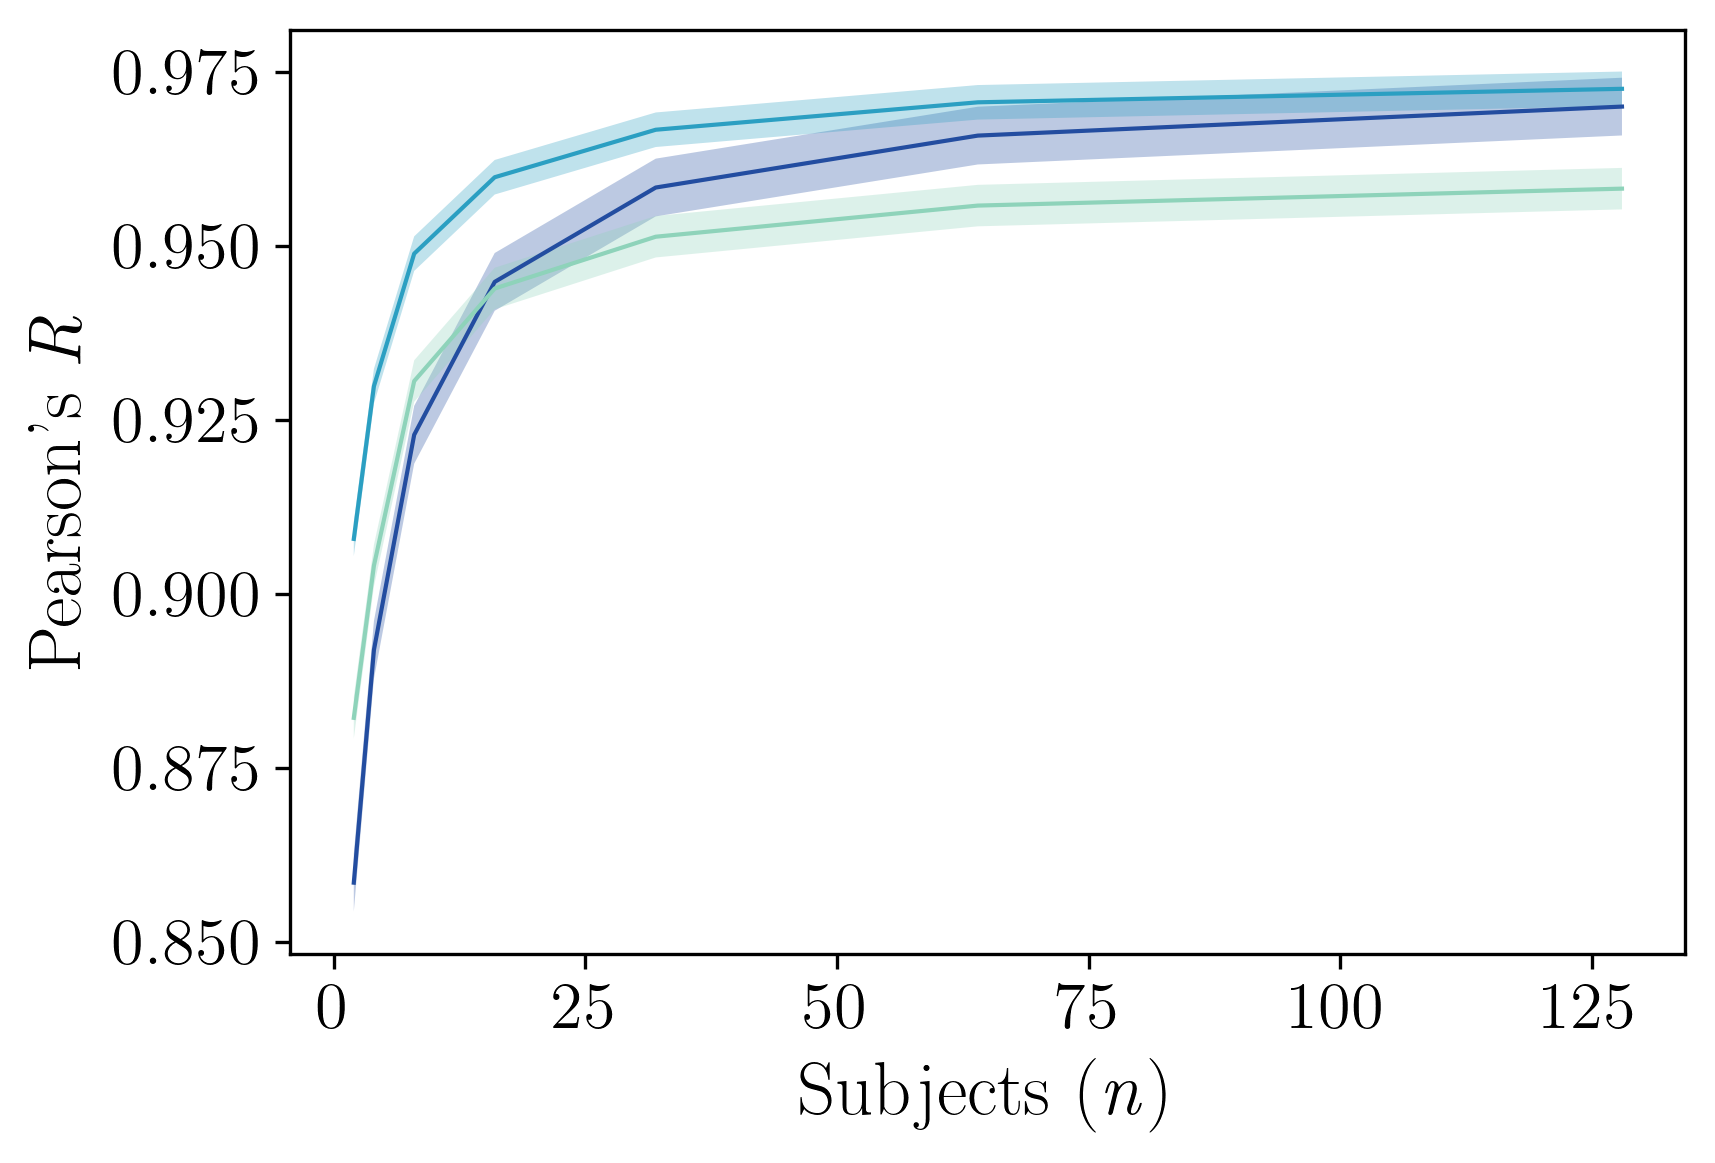

In [62]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300, facecolor="w")

for i_cond in range(n_cond):
    y = R2_cond_av[i_cond,:,:].mean(0)
    yerr = sem(R2_cond_av[i_cond,:,:].flatten())
    # Shaded error region
    ax.fill_between(v_n, y - yerr*2.58, y + yerr*2.58, alpha=0.3, color=colors[i_cond*3],edgecolor='none')
    # Line plot
    ax.plot(v_n, y, color=colors[i_cond*3], linewidth=1)

ax.set_ylabel('Pearson\'s $\mathit{R}$', fontsize=18)
ax.set_xlabel('Subjects ($\mathit{n}$)', fontsize=18)

ax.tick_params(axis='both', labelsize=16)


fname = out_pth + '/MOU-rDCM_Alignment.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')

plt.show()

Group‑level convergence emerges around 20 subjects.

## Graph metrics

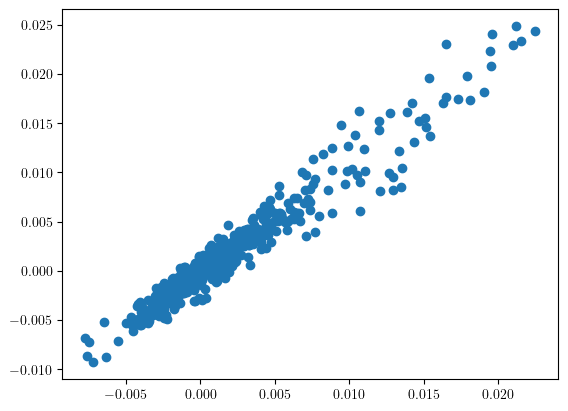

In [21]:
# graph from average connectivity
i_cond = 0
plt.scatter(EC_normed_MOU[i_cond,:,:,:].mean(0), EC_normed_rDCM[i_cond,:,:,:].mean(0))
#plt.plot([-2,4],[-2,4],'--k')

In [22]:
G_av_mou = []
G_av_dcm = []

for i_cond in range(n_cond):

    G_av_mou.append(nx.DiGraph())
    for i in range(n_rois): # source
        for j in range(n_rois): # target
            if i != j:
                G_av_mou[i_cond].add_weighted_edges_from([(i,j,EC_normed_MOU[i_cond,:,i,j].mean(0))])

    G_av_dcm.append(nx.DiGraph())
    for i in range(n_rois): # source
        for j in range(n_rois): # target
            if i != j:
                G_av_dcm[i_cond].add_weighted_edges_from([(i,j,EC_normed_rDCM[i_cond,:,i,j].mean(0))])

print(list(nx.clustering(G_av_mou[0], weight='weight').values()))

[0.013506272637285257, 0.020202785256314314, 0.021362378310677537, 0.04115052982149307, 0.04913767790120809, 0.030076682395583247, 0.004719187114599733, 0.018653914800659654, 0.06409645314033396, 0.04924536916238663, 0.06356894923825612, 0.05776392488176349]


In [23]:
nx.eigenvector_centrality_numpy(G_av_mou[i_cond], weight='weight').values()

dict_values([0.27163866051169433, 0.2128763870062628, 0.2745444287633638, 0.2241297072856641, 0.32667753209726086, 0.2708271495092676, 0.34530712467501273, 0.300103953826289, 0.31951409009037685, 0.26053051373217617, 0.3247938447393352, 0.30077553198897755])

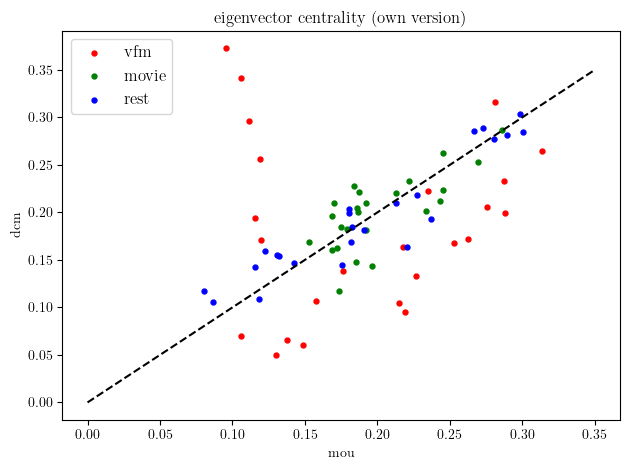

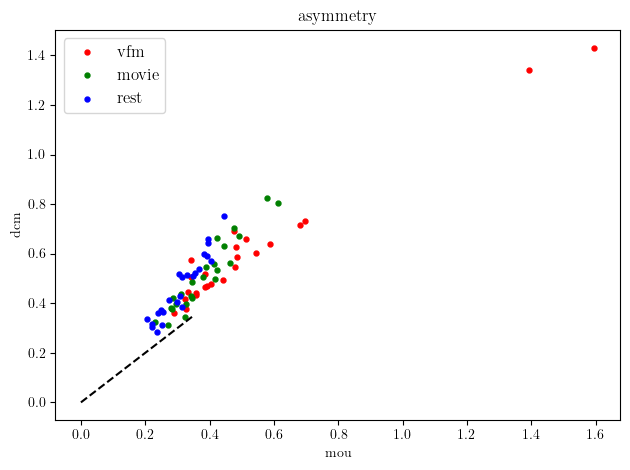

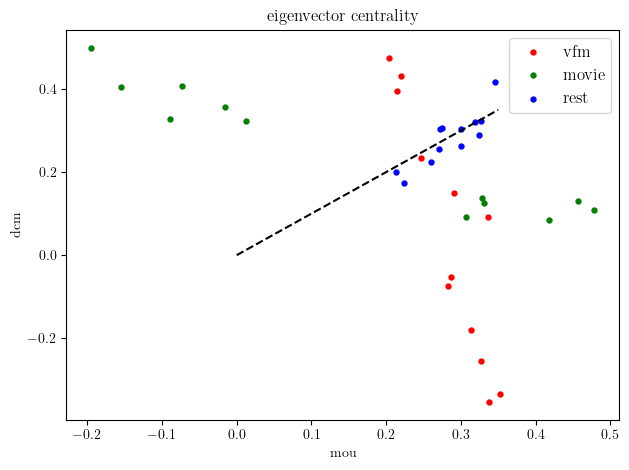

In [25]:
cols = ['r', 'g', 'b']
bins = np.linspace(-0.3, 0.3, 30)

# dominating eigenvector (in previous version I forgot to transpose)
plt.figure()
for i_cond in range(n_cond):
    eigval_mou, eigvec_mou = np.linalg.eig(EC_normed_MOU[i_cond,:,:,:].mean(0).T)
    i_max = np.argmax(np.real(eigval_mou))
    evc_mou = np.abs(eigvec_mou[:,i_max])
    eigval_dcm, eigvec_dcm = np.linalg.eig(EC_normed_rDCM[i_cond,:,:,:].mean(0).T)
    i_max = np.argmax(np.real(eigval_dcm))
    evc_dcm = np.abs(eigvec_dcm[:,i_max])
    plt.scatter(evc_mou, evc_dcm,
                marker='.', s=50, color=cols[i_cond], label=conf['tasks'][i_cond])
plt.plot([0.0,0.35],[0.0,0.35],'--k')
plt.xlabel('mou')
plt.ylabel('dcm')
plt.legend(fontsize=12)
plt.title('eigenvector centrality (own version)')
plt.tight_layout()


# asymmetry for each node
def asym_nodes(M):
    return np.abs(M-M.T).sum(0) / np.abs(M+M.T).sum(0)
    
plt.figure()
for i_cond in range(n_cond):
    plt.scatter(asym_nodes(EC_normed_MOU[i_cond,:,:,:].mean(0)),
                asym_nodes(EC_normed_rDCM[i_cond,:,:,:].mean(0)),
                marker='.', s=50, color=cols[i_cond], label=conf['tasks'][i_cond])
plt.plot([0.0,0.35],[0.0,0.35],'--k')
plt.xlabel('mou')
plt.ylabel('dcm')
plt.legend(fontsize=12)
plt.title('asymmetry')
plt.tight_layout()


# eigenvector centrality from networkx, some instability for movie DCM
plt.figure()
for i_cond in range(n_cond):
    plt.scatter(list(nx.eigenvector_centrality_numpy(G_av_mou[i_cond], weight='weight').values()),
                list(nx.eigenvector_centrality_numpy(G_av_dcm[i_cond], weight='weight').values()),
                marker='.', s=50, color=cols[i_cond], label=conf['tasks'][i_cond])
plt.plot([0.0,0.35],[0.0,0.35],'--k')
plt.xlabel('mou')
plt.ylabel('dcm')
plt.legend(fontsize=12)
plt.title('eigenvector centrality')
plt.tight_layout()



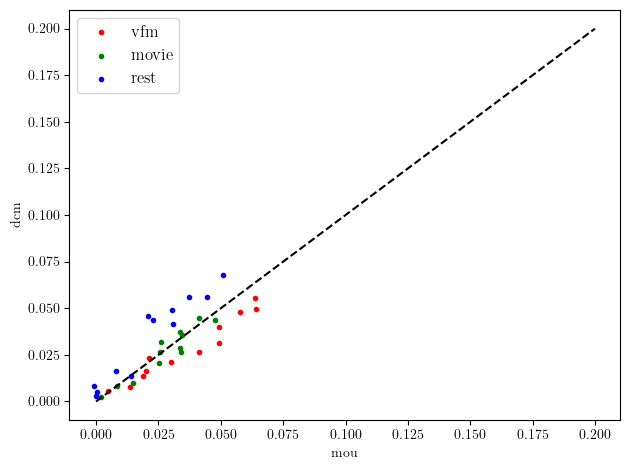

In [26]:
cols = ['r', 'g', 'b']
bins = np.linspace(-0.3, 0.3, 30)

plt.figure()
for i_cond in range(n_cond):
    plt.scatter(list(nx.clustering(G_av_mou[i_cond], weight='weight').values()),
                list(nx.clustering(G_av_dcm[i_cond], weight='weight').values()),
                marker='.', color=cols[i_cond], label=conf['tasks'][i_cond])
plt.plot([0.0,0.2],[0.0,0.2],'--k')
plt.xlabel('mou')
plt.ylabel('dcm')
plt.legend(fontsize=12)
plt.tight_layout()